# Autoencoder
Autoencoder para FashionMNIST

In [22]:
# Import de paquetes
%matplotlib inline
import matplotlib.pyplot as plt
%matplotlib inline
plt.ion()

# Numpy
import numpy as np

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F

# Torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# Dataset
from torchvision.datasets import FashionMNIST

## Hiperparámetros de entrenamiento
latent_dims es el tamaño del bottleneck del autoencoder

In [23]:
learning_rate = 1e-3
use_gpu = False

## Fashion MNIST Dataset

60.000 imágenes en 10 categorias de ropa: Top/T-shirt, Trouser, Pullover, Dress, Coat, Sandar, Shirt, Sneaker, Bag, Anckle Boot. Normalizamos el dataset.

In [24]:
train_dataset = FashionMNIST(root='./data/FashionMNIST', download=True, train=True)
test_dataset = FashionMNIST(root='./data/FashionMNIST', download=True, train=False)

TRAIN_DATA_MEANS = (train_dataset.data / 255.0).mean(axis=(0,1,2))
TRAIN_DATA_STD = (train_dataset.data / 255.0).std(axis=(0,1,2))

TEST_DATA_MEANS = (test_dataset.data / 255.0).mean(axis=(0,1,2))
TEST_DATA_STD = (test_dataset.data / 255.0).std(axis=(0,1,2))

print("Train Data mean", TRAIN_DATA_MEANS)
print("Train Data std", TRAIN_DATA_STD)
print("Test Data mean", TEST_DATA_MEANS)
print("Test Data std", TEST_DATA_STD)

Train Data mean tensor(0.2860)
Train Data std tensor(0.3530)
Test Data mean tensor(0.2868)
Test Data std tensor(0.3524)


In [25]:
batch_size = 128

# normalize data between -1 y 1
img_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) # image = (image - mean) / std
])

train_dataset = FashionMNIST(root='./data/FashionMNIST', download=True, train=True, transform=img_transform)
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

test_dataset = FashionMNIST(root='./data/FashionMNIST', download=True, train=False, transform=img_transform)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

10000


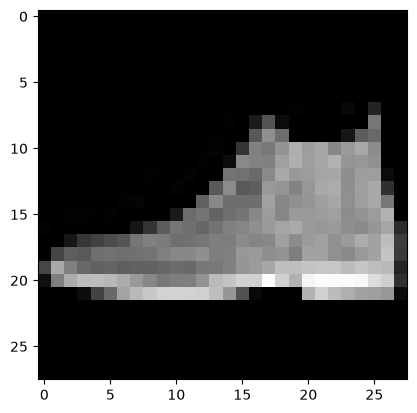

In [26]:
img, label = test_dataset[0]
print(len(test_dataset))

plt.figure()
plt.imshow(img.squeeze(), cmap='gray')

## Autoencoder Definition

Vamos a usar una arquitectura encoder/decoder convolucional.
En los layers convolucionales, incrementamos la cantidad de canales a medida que nos acercamos al bottleneck. A pesar de eso, el número total de features se reduce ya que la cantidad de canales se incrementa en un factor de 2, pero las dimensiones espaciales se reducen por un factor de 4 (https://distill.pub/2016/deconv-checkerboard/)

In [27]:
class Encoder(nn.Module):
    def __init__(self, in_channels = 1, hidden_c=16, latent_dims=10):
        super(Encoder, self).__init__()

        # TODO: Conv-net (2 capas convolucionales + 1 FC)

        self.model = nn.Sequential(
            nn.Conv2d(in_channels=in_channels,
                      out_channels=hidden_c,
                      kernel_size=3),                       # 28x28 -> 26x26
            nn.Tanh(),
            nn.Conv2d(hidden_c, 2*hidden_c, kernel_size=3), # 26x26 -> 24x24
            nn.Tanh(),
            nn.Flatten(),                                   # Flatten
            nn.Linear( 2*hidden_c*24*24, latent_dims)       # 1x10
       )

    def forward(self, x):
        return self.model(x)

class Decoder(nn.Module):
    def __init__(self, out_channels = 1, hidden_c=16, latent_dims=10):
        super(Decoder, self).__init__()

        # TODO: Conv-net (1 FC + 2 capas convolucionales)
        self.linear = nn.Sequential(
            nn.Linear(latent_dims, 2*hidden_c*24*24),
            nn.Tanh()
        )
        # nn.ConvTranspose2d(in_channels=16,  out_channels=16, kernel_size=3)
        self.net = nn.Sequential(
            nn.ConvTranspose2d(in_channels=2*hidden_c,
                               out_channels=hidden_c,
                               kernel_size=3),
            nn.Tanh(),
            nn.ConvTranspose2d(in_channels=hidden_c,
                               out_channels=out_channels,
                               kernel_size=3),
            nn.Tanh()
        )
    def forward(self, x):
        x = self.linear(x)
        x = torch.reshape(x, (x.shape[0], -1, 24, 24))
        x = self.net(x)
        return x

class Autoencoder(nn.Module):
    def __init__(self, in_channels=3, latent_dim=10, hidden_c=16):
        super(Autoencoder, self).__init__()
        self.encoder = Encoder(in_channels=in_channels, latent_dims=latent_dim)
        self.decoder = Decoder(latent_dims=latent_dim)

    def forward(self, x):
        latent = self.encoder(x)
        x_recon = self.decoder(latent)
        return x_recon

In [28]:
autoencoder = Autoencoder(in_channels=1, latent_dim=16)

device = torch.device("cuda:0" if use_gpu and torch.cuda.is_available() else "cpu")
autoencoder = autoencoder.to(device)

In [32]:
from torchinfo import summary

print('Encoder Summary')
encoder = Encoder()
encoder = encoder.to(device)
summary(encoder, input_size=(1, 1, 28, 28))

print('Decoder Summary')
decoder = Decoder()
decoder = decoder.to(device)
summary(decoder, input_size=(1, 10))

print('Full model summary')

summary(autoencoder, input_size=(1, 1, 28, 28))

Encoder Summary
Decoder Summary
Full model summary


Layer (type:depth-idx)                   Output Shape              Param #
Autoencoder                              [1, 1, 28, 28]            --
├─Encoder: 1-1                           [1, 16]                   --
│    └─Sequential: 2-1                   [1, 16]                   --
│    │    └─Conv2d: 3-1                  [1, 16, 26, 26]           160
│    │    └─Tanh: 3-2                    [1, 16, 26, 26]           --
│    │    └─Conv2d: 3-3                  [1, 32, 24, 24]           4,640
│    │    └─Tanh: 3-4                    [1, 32, 24, 24]           --
│    │    └─Flatten: 3-5                 [1, 18432]                --
│    │    └─Linear: 3-6                  [1, 16]                   294,928
├─Decoder: 1-2                           [1, 1, 28, 28]            --
│    └─Sequential: 2-2                   [1, 18432]                --
│    │    └─Linear: 3-7                  [1, 18432]                313,344
│    │    └─Tanh: 3-8                    [1, 18432]                --
│

## Loop de entrenamiento
Para evaluar la calidad de la reconstrucción a cada paso, utilizamos MSE loss https://pytorch.org/docs/stable/nn.html#torch.nn.MSELoss

In [34]:
optimizer = torch.optim.Adam(params=autoencoder.parameters(), lr=learning_rate, weight_decay=1e-5)
num_epochs = 10

# red en modo entrenamiento
autoencoder.train()

train_loss_avg = []

print('Training ...')
for epoch in range(num_epochs):
    train_loss_avg.append(0)
    num_batches = 0

    for image_batch, _ in train_dataloader:

        # TODO: Batch a memoria del dispositivo
        image_batch = image_batch.to(device)
        # TODO: Computar  reconstrucción
        image_batch_hat = autoencoder(image_batch)
        # TODO: Loss
        loss = F.mse_loss(image_batch_hat, image_batch)
        # TODO: backpropagation
        optimizer.zero_grad()
        loss.backward()
        # TODO: paso del optimizador (usando los gradientes computados por backpropagation)
        optimizer.step()
        train_loss_avg[-1] += loss.item()
        num_batches += 1

    train_loss_avg[-1] /= num_batches
    print('Epoch [%d / %d] average reconstruction error: %f' % (epoch+1, num_epochs, train_loss_avg[-1]))

Training ...
Epoch [1 / 10] average reconstruction error: 0.048658
Epoch [2 / 10] average reconstruction error: 0.046725
Epoch [3 / 10] average reconstruction error: 0.045764
Epoch [4 / 10] average reconstruction error: 0.045007
Epoch [5 / 10] average reconstruction error: 0.044338
Epoch [6 / 10] average reconstruction error: 0.043765
Epoch [7 / 10] average reconstruction error: 0.043253
Epoch [8 / 10] average reconstruction error: 0.042858
Epoch [9 / 10] average reconstruction error: 0.042374
Epoch [10 / 10] average reconstruction error: 0.042072


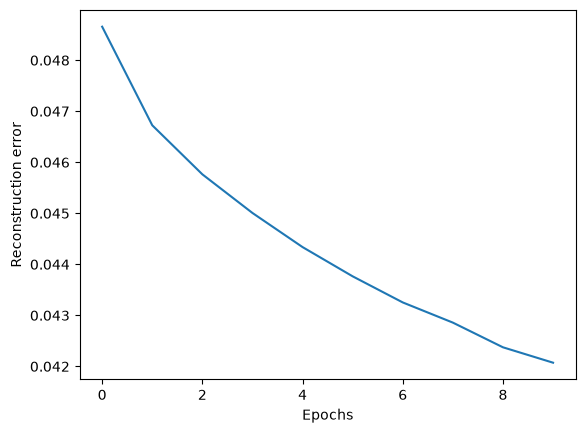

In [35]:
fig = plt.figure()
plt.plot(train_loss_avg)
plt.xlabel('Epochs')
plt.ylabel('Reconstruction error')
plt.show()

### Saving the model

In [36]:
PATH = '.'
MODEL_NAME = 'autoencoder.pt'
torch.save(autoencoder.state_dict(), PATH + MODEL_NAME)

### Loading the model

In [37]:
autoencoder = Autoencoder(in_channels=1, latent_dim=16)
autoencoder.load_state_dict(torch.load(PATH + MODEL_NAME))

<All keys matched successfully>

## Evaluación

In [49]:
device = torch.device("cuda:0" if use_gpu and torch.cuda.is_available() else "cpu")
autoencoder = autoencoder.to(device)

In [50]:
def to_img(x):
    x = 0.5 * (x + 1)
    x = x.clamp(0, 1)
    return x.squeeze()

torch.Size([1, 28, 28])


(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

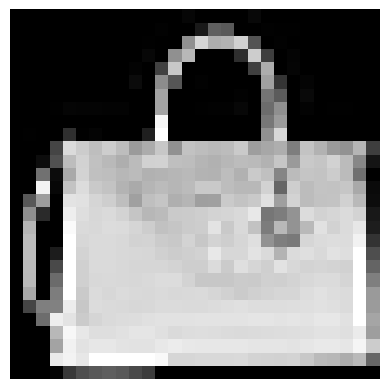

In [66]:
img_test, _ = test_dataset[30]
img2show = to_img(img_test)
print(img_test.shape)

plt.figure()
plt.imshow(img2show, cmap='gray')
plt.axis('off')

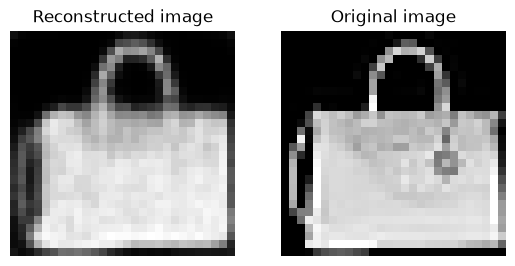

In [70]:
autoencoder.eval()

with torch.no_grad():
  img = img_test.unsqueeze(dim=0)
  img_hat = autoencoder(img.to(device))

img_hat = to_img(img_hat)
plt.Figure()
plt.subplot(1, 2, 1)
plt.imshow(img_hat.to('cpu'), cmap = 'gray')
plt.title('Reconstructed image')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(img2show, cmap = 'gray')
plt.title('Original image')
plt.axis('off')
plt.show()

In [71]:
# red en modo evaluación
autoencoder.eval()

test_loss_avg, num_batches = 0, 0
for image_batch, _ in test_dataloader:

    with torch.no_grad():

        # TODO: Batch a memoria del dispositivo
        image_batch = image_batch.to(device)
        # TODO: Computar reconstrucciones
        image_batch_hat = autoencoder(image_batch)
        # TODO: Evaluamos el error de reconstrucción
        loss = F.mse_loss(image_batch_hat, image_batch)
        test_loss_avg += loss.item()
        num_batches += 1

test_loss_avg /= num_batches
print('average reconstruction error: %f' % (test_loss_avg))

average reconstruction error: 0.043004


## Generate new images from noise using the decoder

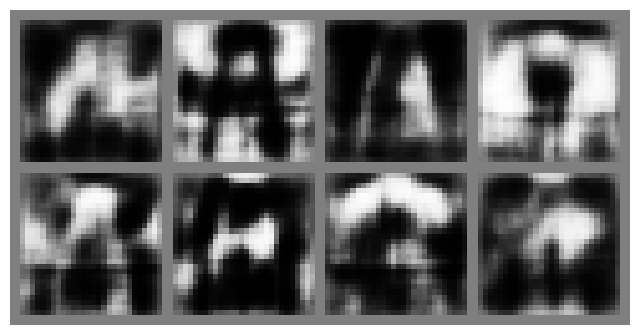

In [75]:
import torchvision

latent_vectors = torch.randn(8, 16, device=device)
autoencoder.eval()

with torch.no_grad():
  new_imgs = autoencoder.decoder(latent_vectors)
  new_imgs = new_imgs.cpu()

grid = torchvision.utils.make_grid(
  new_imgs, nrow=4, normalize=True, pad_value=0.5)
grid = grid.permute(1, 2, 0)
plt.figure(figsize=(8,5))
plt.imshow(grid)
plt.axis('off')
plt.show()